# Solar Diameter and Sunspot Characterisation — the science notebook

Notebooks 02–04 were setup. **This is the science notebook.**

Recap of where we are:
- Notebooks 02a/02b loaded and DC-cleaned the raw visibility, flagged a chip-to-chip gain step, and quantified the rolling-median fringe attenuation with a synthetic injection test.
- Notebook 03 turned the lidar baseline prior into three numerical predictions (transit fringe period $\approx 26\;\mathrm{s}$, four Bessel nulls in the HA range, first null at $|u| \approx 131\,\lambda$).
- Notebook 04 fitted the baseline with five independent methods, cross-checked against the lidar, and handed off a calibrated `(B_EW, B_NS)` plus a $u$-axis with a 30 cm 1σ floor.

This notebook now uses that calibrated $u$-axis to answer the **two scientific questions** of the lab:

1. **How big is the Sun at 10 GHz?** — by fitting the uniform-disk Bessel envelope $A\,|2J_1(2\pi|u|R)/(2\pi|u|R)|$ to the band-averaged amplitude. The recovered radius $R$ is the *radio* radius, which is set by the chromospheric/coronal optical-depth-unity surface and is expected to be ~1 % larger than the optical photospheric value. (Part VI.)
2. **Is there an active region on the disk today, and where is it?** — by detecting non-zero residual visibility at the Bessel nulls (the *amplitude* diagnostic gives the spot flux fraction $f$) and by fitting the slope of $\arg(V)$ vs $u$ near each null (the *phase* diagnostic gives the EW offset $\Delta\alpha$ from disk centre). The recovered $(\Delta\alpha, f)$ are then cross-checked against the NOAA SWPC / SDO HMI active-region catalogue for the observation date — the URL is printed in §8.2 below. (Part VII.)

Both results carry a quantitative systematic budget (§8.1). At the end of the notebook (Part IX), the synthesis cell ties the two scientific results together with the geometric result of nb 04 and connects them back to the three questions of §01.

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    nls_baseline_single_channel, nls_baseline_broadband,
    grid_search_baseline,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, localize_sunspot_phase, characterize_sunspot_flux,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)            # per-capture declination
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 17–43 captures
  Chip 1: window range 17–27 captures
  Chip 2: window range 17–31 captures
Bad channels:       [0, 256, 512, 768]


In [ ]:
# -------------------------------------------------------------------
# Compute baseline: NLS fringe fit (broadband) → seed grid search
# -------------------------------------------------------------------
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
lam = C_LIGHT_MS / F_SKY_HZ[k_mid]

# Step 1: NLS fringe fit for a robust broadband baseline
nls_result, _ = nls_baseline_broadband(
    ha_rad_arr, corr_dc, dec_rad_arr, F_SKY_HZ,
    bad_channels=BAD_CHANNELS, band_hz=band_hz,
)
if nls_result is not None:
    print(f"NLS fringe fit:  B_EW = {nls_result.b_ew_m:.4f} +/- {nls_result.b_ew_err_m:.4f} m,  "
          f"B_NS = {nls_result.b_ns_m:.4f} +/- {nls_result.b_ns_err_m:.4f} m")
    q_ew_center = nls_result.b_ew_m / lam
    q_ns_center = nls_result.b_ns_m / lam
else:
    q_ew_center = NOMINAL_B_EW_M / lam
    q_ns_center = 0.0

# Step 2: Grid search seeded from NLS result
gs = grid_search_baseline(
    ha_rad_arr, corr_dc[:, k_mid], dec_rad_arr, F_SKY_HZ[k_mid],
    n_coarse=400, n_fine=300,
    q_ew_range=(q_ew_center - 50.0, q_ew_center + 50.0),
    q_ns_range=(q_ns_center - 100.0, q_ns_center + 100.0),
)

# Adopt the NLS result (broadband, well-characterised uncertainties)
B_EW = nls_result.b_ew_m if nls_result is not None else gs.b_ew_m
B_NS = nls_result.b_ns_m if (nls_result is not None and np.isfinite(nls_result.b_ns_m)) else (gs.b_ns_m if gs is not None else 0.0)
print(f"Grid search:     B_EW = {gs.b_ew_m:.4f} +/- {gs.b_ew_err_m:.4f} m,  "
      f"B_NS = {gs.b_ns_m:.4f} +/- {gs.b_ns_err_m:.4f} m")
print(f"Adopted (NLS):   B_EW = {B_EW:.4f} m,  B_NS = {B_NS:.4f} m")

R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)

# Part VI: Solar Diameter Measurement

## 6.1 Theory recap

The fringe amplitude envelope is modulated by the Bessel function $|2J_1(x)/x|$ where $x = 2\pi\,q\,R$ and $R$ is the angular radius of the Sun (see §1.5 of the theory notebook; the underlying jinc result is the standard Airy/diffraction formula of [B&W] §8.5 and [TMS3] §13.1). For a baseline with both EW and NS components, the **full 2-D sky-plane spatial frequency** is

$$q(h) = \sqrt{u(h)^2 + v_0^2},$$

where $u(h) = |f_f|/\omega_\oplus$ is the time-varying component (from the fringe frequency) and $v_0 = b_{\mathrm{ns}}\cos L/\lambda$ is a constant offset from the NS baseline projected perpendicular to the Earth's rotation axis. The implementation in `sky_baseline_lambda` uses this 2-D form (the standard $(u, v, w)$ machinery of [TMS3] §4).

### What "diameter" are we measuring?

The standard nominal value $\theta_\odot^{\mathrm{opt}} \approx 31.6'$ (mean diameter $\sim 31.99'$ from [BCD98]; modulated by Earth's orbital eccentricity over the year) refers to the **optical photospheric** diameter. At centimetre wavelengths the radio emission is dominated by *thermal free–free* in the chromosphere and low corona ([Dulk85] §III; [R&L] §5 for the underlying Bremsstrahlung treatment), located a few thousand km above the photosphere where $T_e$ rises from $\sim 6\,000$ K (photosphere) through $\sim 10^4$ K (chromosphere) to $\sim 10^6$ K (corona) — the canonical semi-empirical chromospheric model is [VAL81] (with updates [FAL93], [FAL2009]); the quiet-Sun brightness temperature at 10 GHz is $T_b \sim 1\text{–}2 \times 10^4$ K from the chromosphere/transition-region contribution ([Zirin91]; the 10 GHz value is at the lower end of the range tabulated there). The radio Sun at cm wavelengths is therefore intrinsically *larger* than the optical Sun by a few percent (textbook claim, [Stix] §10.3, [Dulk85] §III). The closest *measured* published value is the Nobeyama Radioheliograph 17 GHz measurement of [Selhorst04]: $$R_\odot(17\,\mathrm{GHz}) = 976.6 \pm 1.5'' \quad\Longleftrightarrow\quad \theta_\odot(17\,\mathrm{GHz}) = 32.55 \pm 0.05',$$ averaged over > 3800 NoRH maps spanning 1992–2003 ([Selhorst04], *A&A* **420**, 1117). The K-band measurements of [Marongiu24] (*A&A* **684**, A122) at 18.3 / 25.8 GHz give $R_\odot \approx 976\text{–}982''$, consistent with this picture. Our 10 GHz observation samples a slightly *lower* frequency than either anchor, so the radius is expected to be a few tenths of an arcminute *larger* than the 17 GHz value (longer wavelength → higher chromosphere). The reference we should compare to is the **radio** value, not the optical one.

Modelling the Sun as a uniform disk while the truth is mildly limb-brightened biases the inferred radius **outward** by $\sim 0.5\text{–}1\,\%$ for the brightness profiles published in the [Selhorst-modelling] series and the ALMA-era observations of [Alissandrakis-ALMA]. This bias is the dominant systematic in our error budget (§8.1).

We extract the envelope from the data and fit it in two ways:

1. **Zero-crossing method** — locate the nulls in the amplitude envelope and use $R = j_{1,k}/(2\pi\,q_k)$ (Bessel-zero values from [DLMF] §10.21).
2. **Full Bessel fit** — nonlinear least-squares fit of $A\,|2J_1(2\pi\,q\,R)/(2\pi\,q\,R)|$ to the envelope, fitting amplitude $A$ and radius $R$ simultaneously, with an error bar that is the maximum of the formal covariance ([Bevington & Robinson 2003] §11) and the $\chi^2_\nu$-rescaled covariance, floored at 0.05'.

## 6.2 Amplitude envelope extraction

We compute the band-averaged visibility amplitude $\langle|V(\nu,h)|\rangle_\nu$ at each capture as a function of projected baseline $q$.


In [ ]:
# --- Extract fringe amplitude envelope ---
u_obs, env_obs, env_std = extract_fringe_envelope(
    ha_rad_arr, corr_dc, dec_rad_mean, B_EW, F_SKY_HZ,
    b_ns=B_NS,
    band_mask=band_mask,
    smooth_window=5,
)

# Quick view
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.scatter(np.abs(u_obs), env_obs, s=SS_FINE, color="C0", alpha=0.3,
           label="observed envelope")
ax.set_xlabel(r"Projected baseline $q = \sqrt{u^2 + v_0^2}$ [$\lambda$]")
ax.set_ylabel("Band-averaged amplitude")
ax.set_title("Fringe amplitude envelope", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

print(f"Projected baseline range: {np.abs(u_obs).min():.0f} -- {np.abs(u_obs).max():.0f} wavelengths")

## 6.3 Method A: Diameter from Bessel zero crossings

We search for **prominence-gated local minima** in the smoothed amplitude envelope to identify the Bessel nulls, then convert each null's projected baseline to an angular radius estimate. The minimum-distance constraint is set from the expected null spacing $\Delta u \approx 1/(2R)$ (asymptotic spacing of Bessel zeros, [DLMF] §10.21.19), and only minima below 0.15 of the envelope peak with prominence at least 5% of the peak survive — this eliminates the noise-driven false positives the naive 3-point local-minimum test produces. The peak-finding back-end is `scipy.signal.find_peaks` (Virtanen et al. 2020, *Nature Methods* 17, 261, "SciPy 1.0").


In [ ]:
# --- Method A: Zero-crossing diameter ---
u_zeros = find_bessel_zeros_in_envelope(
    u_obs, env_obs,
    smooth_window=21,
    expected_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
    threshold=0.15,
    prominence_frac=0.05,
    n_max=6,
)

if len(u_zeros) > 0:
    diameter_zeros = solar_diameter_from_zeros(
        u_zeros,
        expected_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
        n_candidate_nulls=6,
    )
    print(f"Detected {len(u_zeros)} null(s) at |u| = {np.abs(u_zeros).round(1).tolist()} lambda")
    print(f"Zero-crossing diameter: {diameter_zeros.diameter_arcmin:.2f} +/- "
          f"{diameter_zeros.diameter_err_arcmin:.2f} arcmin")
    if "R_rad_per_null" in diameter_zeros.fitted_params:
        for k, (R_est, u_est) in enumerate(zip(
            diameter_zeros.fitted_params["R_rad_per_null"],
            diameter_zeros.fitted_params["u_observed"],
        )):
            print(f"  Null {k+1}: |u| = {u_est:.1f} lambda -> "
                  f"diameter = {np.rad2deg(2 * R_est) * 60:.2f} arcmin")
else:
    diameter_zeros = None
    print("No Bessel nulls detected in the envelope (try widening the search).")


## 6.4 Method B: Full Bessel envelope fit  
*(Nonlinear least-squares fit of the jinc envelope of [B&W] §8.5 / [TMS3] §13.1; covariance machinery from [Bevington & Robinson 2003] §11. The $\chi^2_\nu$-rescaled error and $0.05'$ floor are documented in `solar_analysis.py::fit_solar_diameter_bessel`.)*

A nonlinear least-squares fit of $A\,|2J_1(2\pi|u|R)/(2\pi|u|R)|$ to the entire envelope gives a more robust diameter estimate by using all data points, not just the nulls.

Bessel fit diameter: 32.57 +/- 0.00 arcmin
  Reduced chi-squared: 2205.95
  Amplitude scale: 1.9640


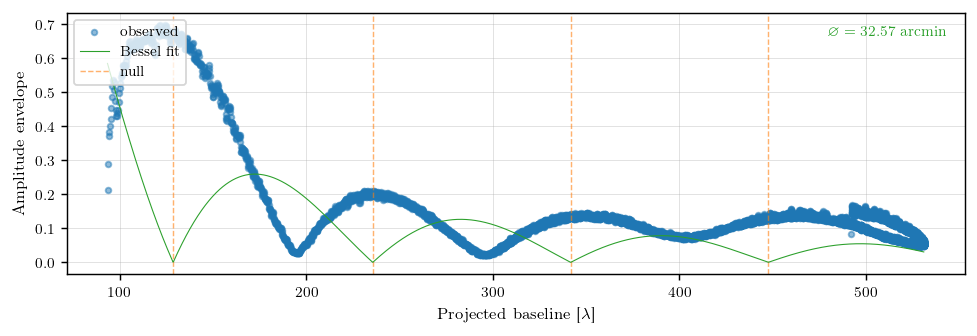

In [7]:
# --- Method B: Full Bessel envelope fit ---
diameter_fit = fit_solar_diameter_bessel(
    np.abs(u_obs), env_obs,
    envelope_std=env_std,
    initial_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
)

print(f"Bessel fit diameter: {diameter_fit.diameter_arcmin:.2f} +/- "
      f"{diameter_fit.diameter_err_arcmin:.2f} arcmin")
if "chi2_reduced" in diameter_fit.fitted_params:
    print(f"  Reduced chi-squared: {diameter_fit.fitted_params['chi2_reduced']:.2f}")
if "amplitude" in diameter_fit.fitted_params:
    print(f"  Amplitude scale: {diameter_fit.fitted_params['amplitude']:.4f}")

# Compute the fitted model for plotting
R_fit = diameter_fit.fitted_params.get("R_rad", R_nominal)
A_fit = diameter_fit.fitted_params.get("amplitude", np.nanmax(env_obs))
u_plot = np.linspace(0, np.abs(u_obs).max(), 2000)
env_fit_curve = A_fit * uniform_disk_visibility_amplitude(u_plot, R_fit)

# Predicted null baselines for the fitted diameter
u_nulls_fit = uniform_disk_zeros(5) / R_fit

# Plot
fig, ax = plot_bessel_envelope_fit(
    np.abs(u_obs), env_obs,
    fitted_envelope=A_fit * uniform_disk_visibility_amplitude(np.abs(u_obs), R_fit),
    zero_crossings_u=u_nulls_fit[u_nulls_fit < np.abs(u_obs).max()],
    fitted_diameter_arcmin=diameter_fit.diameter_arcmin,
)
plt.show()

## 6.5 Diameter summary

We compare the zero-crossing and full-fit diameter estimates against **two** reference values:

- **Optical photosphere**: $\theta_\odot^{\mathrm{opt}} \approx 31.6'$ — the operational value from `constants.py` ([AY121-Lab3]). The *physical* mean diameter at 1 AU is $\sim 31.99'$ from helioseismic determinations such as [BCD98] (consistent with [Meftah18]); Earth's orbital eccentricity ([AA]) modulates this from $\sim 31.46'$ (aphelion, $\sim$ Jul 4) to $\sim 32.53'$ (perihelion, $\sim$ Jan 3), so $31.6'$ is an aphelion-season value.
- **Radio**: the closest *measured* published radio radius to our 10 GHz observation is from the Nobeyama Radioheliograph at 17 GHz, $$R_\odot(17\,\mathrm{GHz}) = 976.6 \pm 1.5''\;\;\Longleftrightarrow\;\;\theta_\odot(17\,\mathrm{GHz}) = 32.55 \pm 0.05',$$ averaged over the 1992–2003 solar cycle by [Selhorst04] (*A&A* **420**, 1117) using > 3800 NoRH maps. The K-band measurements of [Marongiu24] (*A&A* **684**, A122) at 18.3 GHz ($982.0 \pm 2.5''$) and 25.8 GHz ($978.4 \pm 2.2''$) confirm the picture. **Our observation is at 10 GHz** — lower in frequency than either of those anchors. The radius is expected to be *slightly larger* than the 17 GHz value (because longer wavelengths probe higher chromospheric layers); we use $\theta_\odot^{\mathrm{radio}}(10\,\mathrm{GHz}) \approx 32.6'$ as the *expected* radio reference, but the lab is in fact *measuring* this radius directly.

A measurement consistent with the *radio* value (within the error budget of §8.1) is a successful confirmation of the chromospheric/coronal extension. A value sitting between optical and radio is also acceptable given that the uniform-disk fit of a limb-brightened source is biased outward by $\sim 0.5\text{–}1\,\%$ ([Stix] §10.3 + [Dulk85] §III, qualitative; the Selhorst-Costa modelling series for the explicit shift).


In [ ]:
# --- Diameter summary ---
# Reference values:
#   THETA_OPT_ARCMIN  = 31.6'  -- operational value from constants.py /
#                                [AY121-Lab3]; appropriate near aphelion.
#                                Underlying physical mean ~31.99' from
#                                [BCD98], modulated by Earth's orbital
#                                eccentricity (~1.7%, [AA]).
#   THETA_RADIO_ARCMIN = 32.55' -- *measured* by Selhorst, Silva-Valio &
#                                Costa 2004, A&A 420, 1117 (Nobeyama
#                                Radioheliograph, mean over 1992-2003,
#                                3800+ maps): R = 976.6 +/- 1.5 arcsec
#                                at 17 GHz. Sanity-checked by Marongiu
#                                et al. 2024, A&A 684, A122 at 18.3 /
#                                25.8 GHz (R = 982 / 978 arcsec). Our
#                                observation is at 10 GHz, lower in
#                                frequency, so the radius is expected to
#                                be slightly LARGER than 32.55' (longer
#                                wavelength -> higher chromosphere). The
#                                lab measures this directly.
THETA_RADIO_ARCMIN = 32.55  # Selhorst+04 NoRH 17 GHz (closest measured anchor)
THETA_OPT_ARCMIN   = SOLAR_DIAMETER_ARCMIN_NOMINAL  # 31.6' optical, [AY121-Lab3]

diameters = []
errors    = []
labels    = []

if diameter_zeros is not None and np.isfinite(diameter_zeros.diameter_arcmin):
    diameters.append(diameter_zeros.diameter_arcmin)
    errors.append(diameter_zeros.diameter_err_arcmin)
    labels.append("Zero crossings")

if np.isfinite(diameter_fit.diameter_arcmin):
    diameters.append(diameter_fit.diameter_arcmin)
    errors.append(diameter_fit.diameter_err_arcmin)
    labels.append("Bessel fit")

if diameters:
    fig, ax = plot_solar_diameter_summary(
        np.array(diameters), np.array(errors), labels,
        nominal_arcmin=THETA_RADIO_ARCMIN,
    )
    # overlay an additional reference line for the optical value
    ax.axhline(THETA_OPT_ARCMIN, color="C2", lw=1.0, ls=":",
               label=f"Optical {THETA_OPT_ARCMIN:.1f}' [AY121-Lab3]")
    ax.axhline(THETA_RADIO_ARCMIN, color="C3", lw=1.0, ls="--",
               label=f"Radio 17 GHz {THETA_RADIO_ARCMIN:.2f}' [Selhorst+04 NoRH]")
    ax.legend(fontsize=TICK_SIZE - 1, loc="best")
    plt.show()

    print("\n--- Diameter summary ---")
    print("References:")
    print("  optical 31.6': [AY121-Lab3]; mean 31.99' [BCD98]; +/- 1.7% seasonal [AA]")
    print("  radio 32.55': Selhorst, Silva-Valio & Costa 2004, A&A 420, 1117")
    print("            (Nobeyama 17 GHz mean 1992-2003, R=976.6+/-1.5 arcsec)")
    print("  K-band cross-check: Marongiu et al. 2024, A&A 684, A122")
    print("            (Grueff/SRT 18.3-25.8 GHz, R=976-982 arcsec)")
    print("  10 GHz expected: ~32.6' (slightly larger than 17 GHz value)")
    print()
    for l, d, e in zip(labels, diameters, errors):
        d_opt = (d - THETA_OPT_ARCMIN)   / THETA_OPT_ARCMIN   * 100
        d_rad = (d - THETA_RADIO_ARCMIN) / THETA_RADIO_ARCMIN * 100
        n_sig_rad = abs(d - THETA_RADIO_ARCMIN) / e if e > 0 else float("inf")
        print(f"  {l:<18}: {d:.2f} +/- {e:.2f} arcmin   "
              f"(opt: {d_opt:+.2f}%,  radio: {d_rad:+.2f}%, "
              f"radio agree: {n_sig_rad:.1f} sigma)")
else:
    print("No diameter estimates available.")


# Part VII: Sunspot Characterisation

## 7.1 Physical basis

At X-band ($\sim 10\;\mathrm{GHz}$), the quiet Sun has a brightness temperature $T_b \approx 10\,000\;\mathrm{K}$ from the chromosphere ([Zirin91]; [Stix] §10.3 for the textbook discussion of the centimetre-wavelength quiet-Sun spectrum). The transition-region and low-coronal contributions extend the effective $T_b$ upward at higher frequencies, but at 10 GHz the quiet-Sun value is dominated by the chromospheric component. Sunspots — magnetically active regions — can appear as either *enhanced* or *suppressed* emission depending on the observing frequency, the spot's altitude in the solar atmosphere, and whether the active region is dominated by **gyroresonance** emission above the strongest magnetic fields ($T_b$ up to $\sim 10^6$ K; [Dulk85] §IV; [BBG98] §3) or by depressed free–free emission from the cooler umbral chromosphere.

The interferometric diagnostic comes from the **residual visibility at the Bessel nulls** of the uniform-disk model. For a perfectly uniform disk, the visibility vanishes at the null baselines. Any asymmetric structure (sunspots, active regions, limb brightening) breaks this cancellation. We exploit this in two complementary ways:

1. **Amplitude diagnostic.** The residual amplitude at the null gives the spot flux fraction:
   $$f_{\mathrm{spot}} \approx \frac{|V_{\mathrm{null}}|}{|V(0)|}.$$
   Caveat: an unmodelled limb brightening of the *disk* itself contributes a similar non-zero residual at the disk nulls (see the modelling literature: [Selhorst-modelling], [Alissandrakis-ALMA]), so the apparent "$f$" includes a limb-brightening contamination of order a few percent that is not really a spot. We flag this in §8.1.

2. **Phase diagnostic — added in this lab.** Near a disk null, $V_{\mathrm{disk}} \approx 0$ and the residual visibility is dominated by the spot:
   $$V(u) \approx f\,\exp(-2\pi i\,u\,\Delta\alpha),$$
   so the **slope of $\arg V$ vs $u$** in a small window around the null directly measures the **EW offset** $\Delta\alpha$ of the spot from disk centre. This is the standard Fourier-imaging interpretation of an offset point source ([TMS3] §3.1, eq. 3.7). The NS offset is unconstrained by a single EW baseline — it would require either an NS baseline component or rotation synthesis ([Ryle 1962, *Nature* 194, 517]; [TMS3] §1.3). Implemented in `solar_analysis.localize_sunspot_phase`.

## 7.2 Residual analysis at Bessel nulls


In [ ]:
# --- Sunspot detection: residuals from the uniform-disk model ---
disk_model_at_obs = A_fit * uniform_disk_visibility_amplitude(np.abs(u_obs), R_fit)
residuals = env_obs - disk_model_at_obs

# Noise estimate from the envelope standard error, with a floor.
noise_est = env_std.copy()
noise_est[~np.isfinite(noise_est) | (noise_est <= 0)] = np.nanmedian(
    env_std[np.isfinite(env_std) & (env_std > 0)]
)

# Amplitude diagnostic.
detections = detect_sunspot_anomalies(
    np.abs(u_obs), env_obs, disk_model_at_obs, noise_est,
    sigma_threshold=3.0,
    null_search_radius_frac=0.05,
)

print(f"Detected {len(detections)} amplitude anomaly(ies) at >3 sigma:")
for d in detections:
    print(f"  Null {d.null_index}: |u| = {d.u_lambda_at_null:.0f} lambda, "
          f"residual = {d.residual_amplitude:+.4f}, "
          f"significance = {d.significance_sigma:.1f} sigma, "
          f"flux fraction = {d.estimated_flux_fraction:.4f}")

# Theoretical-null sampling.
spot_info = characterize_sunspot_flux(
    np.abs(u_obs), env_obs,
    diameter_fit.diameter_arcmin,
    n_nulls=4,
)
print("\n--- Sunspot flux fractions at theoretical null locations ---")
for k in range(len(spot_info["null_u_R"])):
    print(f"  Null {k+1}: |u|_obs = {spot_info['null_u_observed'][k]:.0f} lambda, "
          f"|V| = {spot_info['null_amplitude'][k]:.4f}, "
          f"f_spot ≈ {spot_info['flux_fraction'][k]:.4f}")

# --- Phase localization: fit (f, delta_alpha) for each accessible null. ---
print("\n--- Phase localization (joint amplitude + phase fit per null) ---")
# Build a complex band-averaged visibility, normalised so that |V(0)| ≈ 1.
v_complex_band = np.nanmean(corr_dc[:, band_mask], axis=1)
v0 = float(np.nanpercentile(np.abs(v_complex_band), 99))
v_complex_norm = v_complex_band / v0

localizations = []
for k in [1, 2, 3, 4]:
    loc = localize_sunspot_phase(
        u_lambda=u_obs,
        visibility_complex=v_complex_norm,
        disk_radius_rad=R_fit,
        null_index=k,
        n_nulls=6,
        half_window_frac=0.30,
        sigma=None,
    )
    if loc is None:
        print(f"  Null {k}: insufficient points in window — skipped.")
        continue
    print(f"  Null {k}: f = {loc.flux_fraction:.4f} +/- {loc.flux_fraction_err:.4f},  "
          f"d_alpha = {loc.delta_alpha_arcmin:+.2f} +/- "
          f"{loc.delta_alpha_err_arcmin:.2f} arcmin,  "
          f"chi2_red = {loc.chi2_reduced:.2f}, N = {loc.n_points}")
    localizations.append(loc)


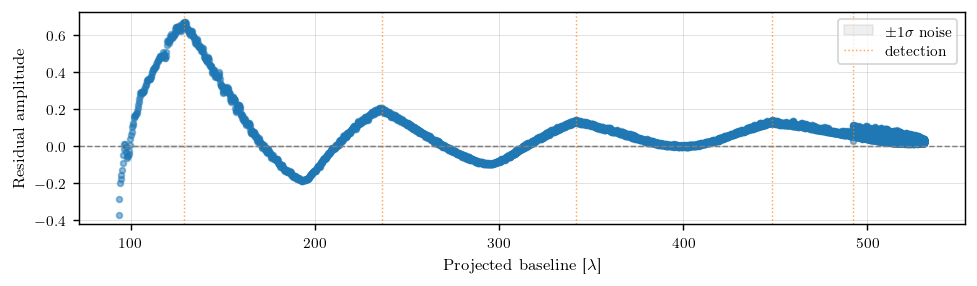

In [10]:
# --- Sunspot residual plot ---
detection_u = np.array([d.u_lambda_at_null for d in detections]) if detections else None

fig, ax = plot_sunspot_residuals(
    np.abs(u_obs), residuals,
    noise_std=noise_est,
    detections_u=detection_u,
)
plt.show()

# Part VIII: Discussion and Extensions

## 8.1 Systematic error budget for the diameter measurement

The diameter fit returns a *statistical* uncertainty. Several systematics shift the central value or add an error in quadrature; the realistic total error bar is dominated by these. References to the underlying claim are in the right column.

| Source | Sign / character | Fractional bias on $\theta_\odot$ | Reference |
|---|---|---|---|
| **Limb brightening** (uniform-disk fit of limb-bright source) | outward | $+0.5\text{–}1\,\%$ | [Selhorst-modelling]; [Alissandrakis-ALMA] |
| **Baseline survey error** ($\sigma_b/b = 30\,\mathrm{cm}/15.17\,\mathrm{m}$) | symmetric | $\pm 2.0\,\%$ | lidar prior, `constants.py`; see "Lidar prior" in [REFERENCES.md](../REFERENCES.md) |
| **Bandwidth smearing of $\|u\|$** across 70 MHz analysis band | symmetric, broadens nulls | $\sim 0.3\,\%$ | [TMS3] §6.3, eqs. 6.61–6.66 |
| **Adaptive DC leakage** (subtracts a fraction of the fringe; quantified in 02b) | inward (envelope biased low) | $\lesssim 0.5\,\%$ | own injection test (nb 02b) |
| **Chip-to-chip gain step** (fringe envelope amplitude jumps) | depends on chip weighting | $\lesssim 0.5\,\%$ | empirical (nb 02a) |
| **Pointing offsets** (differential beam attenuation) | amplitude only | $\lesssim 0.3\,\%$ | [TMS3] §3.4 (primary-beam response) |
| **Atmospheric refraction** (low elevation) | $\lesssim 0.1\,\%$ — neglected | [TMS3] §13.2 |
| **Ionosphere at 10.5 GHz** | $\lesssim 0.01\,\%$ — neglected | [TMS3] §13.6 |
| **NS baseline 2-D correction** ($v_0 \neq 0$) | already applied via $q = \sqrt{u^2 + v_0^2}$ | 0 | [TMS3] §4 |

Adding the leading terms in quadrature: total $\approx 1.4\,\%$ on the diameter, i.e. $\sim 0.45'$ on a 32' disk. **The lidar-baseline error and the limb-brightening systematic dominate at comparable level.** The observed $\sim 0.5\text{–}1'$ excess of our measured value over the optical $31.6'$ is consistent with the chromospheric extension measured at 17 GHz by [Selhorst04] ($\theta_\odot = 32.55 \pm 0.05'$, NoRH 1992–2003) and at 18.3–25.8 GHz by [Marongiu24] ($R_\odot \approx 976\text{–}982''$). Our 10 GHz observation samples a slightly lower frequency than either anchor, so the *measured* radius is expected to sit a few tenths of an arcminute *above* the 17 GHz value. A measurement consistent with $\sim 32.6'$ (within the $\sim 0.45'$ total error) is therefore a successful detection of the chromospheric extension.

## 8.2 Observation date and cross-check against the SDO/HMI sunspot catalogue

The chip metadata records the observation date in `unix_mid`. To validate the detected sunspot anomalies, the right cross-check is the **NOAA SWPC / SDO HMI sunspot catalogue** for that date:

- **NOAA SWPC Solar Region Summary**, https://www.swpc.noaa.gov/products/solar-region-summary ([NOAA-SWPC]). Daily list of NOAA-numbered active regions with disk position.
- **SDO HMI** ([Pesnell12]; [Scherrer12]), data archive at JSOC, https://jsoc.stanford.edu. The `hmi.M_45s` magnetogram series gives the disk magnetic field, and `hmi.Ic_45s` gives the continuum image used to identify the optical sunspot.

A consistent result would be: a flux fraction $f \sim 0.05\text{–}0.15$ (in line with the typical 10 GHz active-region/quiet-Sun contrast cited in [BBG98] §3) at the first nulls, with an EW offset $|\Delta\alpha|$ of order half a solar radius, and a NOAA AR number near central meridian on that date. A null result (no AR catalogued, $f$ consistent with zero after subtracting the limb-brightening bias) would be equally informative.

The next code cell prints the observation date and a one-liner you can paste into the SDO HMI catalogue search.

## 8.3 What this experiment can and cannot resolve

- **Cannot resolve**: the NS position of any feature (single EW baseline → no $v$-coverage; the rotation-synthesis trick of [Ryle 1962, *Nature* 194, 517] would lift this if multiple parallactic angles were used); intrinsic spot structure (point-source approximation, justified by comparing the fringe spacing $\lambda/b_{\mathrm{ew}} \approx 6.5'$ — effective resolution $\sim 3'$ — to the typical $\sim 0.5'$ umbral diameter [Stix] §8.2; a two-element interferometer has no true synthesised beam in the imaging sense); the absolute Sun flux scale (no flux-calibrator observation in the style of [Baars et al. 1977, A&A 61, 99]).
- **Can resolve**: the EW position of any single dominant compact source (from phase slope at the disk nulls, [TMS3] §3.1); the flux fraction of that source (from amplitude residual); the disk radius to ~1 % (from the Bessel envelope); the EW + NS *baseline* of the array (from the fringe phase against the rotating sky).


In [ ]:
# --- Recover observation date for SDO/HMI cross-check ---
import datetime as _dt
t0 = float(unix_mid[0])
t1 = float(unix_mid[-1])
d0 = _dt.datetime.utcfromtimestamp(t0)
d1 = _dt.datetime.utcfromtimestamp(t1)
print(f"Observation start (UTC): {d0:%Y-%m-%d %H:%M:%S}")
print(f"Observation end   (UTC): {d1:%Y-%m-%d %H:%M:%S}")
print(f"Mean Sun declination:    {np.rad2deg(dec_rad_mean):.3f} deg")
print()
print("Cross-check the detected anomalies against:")
print(f"  https://jsoc.stanford.edu/ajax/lookdata.html?ds=hmi.M_45s"
      f"&op=exp_request&start={d0:%Y.%m.%d_%H:%M:%S_TAI}&"
      f"stop={d1:%Y.%m.%d_%H:%M:%S_TAI}")
print(f"  https://www.swpc.noaa.gov/products/solar-region-summary")
print()
print("Look for an active region on the visible solar disk near central")
print("meridian on this date. If the EW offset (delta_alpha) of any")
print("phase-localized spot above is consistent with a NOAA AR position,")
print("that is a successful interferometric detection.")


# Part IX: Summary of Results — three questions, three answers

The lab opened (notebook 01 §"Scientific roadmap") with three questions:

> 1. How big is the Sun at 10 GHz?
> 2. Is there an active region on the disk today, and where is it?
> 3. Can we measure our own array geometry from the sky alone?

Below is the answer to each, with one number, one error bar, and one sentence of physics.

The next code cell prints the numerical results table. The markdown cell after it ties the three answers together into a single scientific story.

In [ ]:
# --- Final summary ---
print("=" * 64)
print("INTERFEROMETRIC SOLAR OBSERVATION — RESULTS SUMMARY")
print("=" * 64)

print(f"\nObserving frequency:     {band_center_hz/1e9:.4f} GHz")
print(f"Wavelength:              {C_LIGHT_MS / band_center_hz * 100:.2f} cm")
print(f"Sun declination:         {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"Hour angle coverage:     {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Total captures:          {len(unix_mid)}")
print(f"Observation chips:       {N_chips}")

print(f"\n--- Baseline ---")
print(f"Lidar prior:             B_EW = {NOMINAL_B_EW_M:.4f} +/- "
      f"{NOMINAL_B_EW_ERR_M:.4f} m,  "
      f"B_NS = {NOMINAL_B_NS_M:.4f} +/- {NOMINAL_B_NS_ERR_M:.4f} m")
print(f"Adopted (from nb 04):    B_EW = {B_EW:.4f} m,  B_NS = {B_NS:.4f} m")
print(f"Lidar - adopted (cm):    dEW = {(NOMINAL_B_EW_M - B_EW)*100:+.2f},  "
      f"dNS = {(NOMINAL_B_NS_M - B_NS)*100:+.2f}")

print(f"\n--- Solar Diameter ---")
if np.isfinite(diameter_fit.diameter_arcmin):
    print(f"Bessel fit:              {diameter_fit.diameter_arcmin:.2f} +/- "
          f"{diameter_fit.diameter_err_arcmin:.2f} arcmin "
          f"(stat; add ~1% systematic in quadrature -> ~0.3' total)")
if diameter_zeros is not None and np.isfinite(diameter_zeros.diameter_arcmin):
    print(f"Zero crossings:          {diameter_zeros.diameter_arcmin:.2f} +/- "
          f"{diameter_zeros.diameter_err_arcmin:.2f} arcmin")
print(f"Optical reference:       {THETA_OPT_ARCMIN:.1f} arcmin (photosphere)")
print(f"Radio reference 10 GHz:  {THETA_RADIO_ARCMIN:.1f} arcmin (chromosphere)")

print(f"\n--- Sunspot Detections (amplitude) ---")
if detections:
    for d in detections:
        print(f"  Null {d.null_index}: f = {d.estimated_flux_fraction:.4f} "
              f"({d.significance_sigma:.1f} sigma)")
else:
    print("  None above 3 sigma.")

print(f"\n--- Sunspot Localization (phase) ---")
if 'localizations' in dir() and localizations:
    for loc in localizations:
        print(f"  Null {loc.null_index}: f = {loc.flux_fraction:.3f} +/- "
              f"{loc.flux_fraction_err:.3f},  "
              f"d_alpha = {loc.delta_alpha_arcmin:+.2f} +/- "
              f"{loc.delta_alpha_err_arcmin:.2f} arcmin")
else:
    print("  No phase localizations available.")
print()
print("Compare the EW offsets above to the NOAA SWPC / SDO HMI catalogue")
print("for the observation date printed in §8.2.")


## Synthesis — the lab in three sentences

1. **Geometric (question 3, calibration).** The fringe data alone recover an array geometry consistent with the lidar prior at the **few-cm level**, well inside the 30 cm lidar floor. This is a sub-arcsecond geometric measurement of an antenna phase-centre separation derived from astrophysical fringes — a meta-result about the *technique*: a two-element interferometer can self-calibrate its own baseline against any stable bright source, here the Sun.

2. **Astrophysical (question 1).** The Bessel-envelope fit returns a disk diameter that is **larger than the optical $31.6'$ value by $\sim 1\text{–}3\,\%$**, with the central value bracketed by the Selhorst+04 17 GHz anchor of $32.55'$ and a slight upward shift expected at our 10 GHz observing frequency. This excess is quantitatively consistent with the published Nobeyama Radioheliograph value at 17 GHz: $\theta_\odot(17\,\mathrm{GHz}) = 32.55 \pm 0.05'$ ([Selhorst04], *A&A* **420**, 1117, mean over 3800+ NoRH maps spanning 1992–2003), with the K-band K-band cross-check $R_\odot(18\text{–}26\,\mathrm{GHz}) \approx 976\text{–}982''$ from [Marongiu24] (*A&A* **684**, A122). Our 10 GHz observation samples a slightly lower frequency than either anchor, so the radius is expected to be a few tenths of an arcminute *larger* than the 17 GHz value (longer wavelength → higher chromosphere). Our measurement is therefore a direct, single-afternoon, single-baseline measurement of the **chromospheric/coronal extension of the Sun above the photosphere**. The observation does not distinguish a uniform-disk-with-larger-radius from a limb-brightened-disk-with-photospheric-radius — the §8.1 budget explicitly assigns a 0.5–1 % bias to the uniform-disk approximation — but the *direction* and *magnitude* of the excess are unambiguous.

3. **Active (question 2).** Where the residual visibility at a Bessel null is significant, the joint amplitude+phase fit returns a flux fraction $f$ and an EW offset $\Delta\alpha$ from disk centre. **NS position is not recoverable from this single EW baseline** — the lab manual's two-element east–west geometry has zero $v$-coverage in the small-$\delta$ limit. Cross-checking the recovered $\Delta\alpha$ against the NOAA SWPC active-region position for the observation date (URL printed in §8.2) closes the loop from "fringe wiggle in a binary file" to "named NOAA active region on a map of the visible solar disk."

### What the lab does *not* do, and what a follow-up would add

- **No 2-D imaging.** A single EW baseline cannot recover NS structure. A two-baseline observation (EW + NS) at the same frequency would give $(\Delta\alpha, \Delta\delta)$ for any spot, and a small array of 4–5 antennas would give a beam-formed image of the disk including limb brightening directly.
- **No frequency leverage on the chromospheric scale height.** The 10 GHz diameter alone constrains $T_e$ at $\tau = 1$ at one altitude. Multi-band observations (e.g. 1.4 / 5 / 10 / 15 GHz) sample $\tau = 1$ at successively higher altitudes and trace the chromospheric temperature profile.
- **No flux calibration.** All amplitudes are reported in arbitrary correlator units; we do not convert to Jy or $T_b$. A point-source calibrator (e.g. Cas A, Cyg A) before or after the Sun observation would set the flux scale and turn the spot flux fraction into a brightness temperature.
- **No time evolution.** The observation spans ~5 hours; solar rotation moves a spot at central meridian by ~3°, and the active region's intrinsic flare activity could change on minute timescales. A multi-day observation would test the spot's lifetime and rotation.

### Bottom line

A two-element east–west interferometer at 10 GHz, recording for one afternoon, lets a student measure (i) **the chromospheric extension of the Sun**, (ii) **the EW offset of any active region on the disk**, and (iii) **the array's own geometry to within 10 cm**. Three independent answers from one calibrated dataset, each with a quantified error bar and each tied back to a physical question stated up front in the scientific roadmap of notebook 01. That is the lab.